In [1]:
from tqec.computation.prism import BasisPrism, Position3DHex
from tqec.computation.pipe_prism import PrismPipeKind
from tqec.computation.prism_graph import PrismGraph

from tqec.computation.correlation import find_correlation_surfaces
from tqec.compile.observables.abstract_observable import (
    AbstractObservable,
    compile_correlation_surface_to_abstract_observable,
)

### Teleportation

In [2]:
g = PrismGraph("teleportation")

prisms = [
    (Position3DHex(0,0,0), "Port", "start"),
    (Position3DHex(0,0,1), "NZ", "1"),
    (Position3DHex(-1,1,1), "ZN", "2"),
    (Position3DHex(-1,1,2), "Port", "end"),

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [3]:
#start-1
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

#1-2
pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

#2-end
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

In [4]:
g.view_as_html()

(<Figure size 500x600 with 1 Axes>, <Axes3D: >)

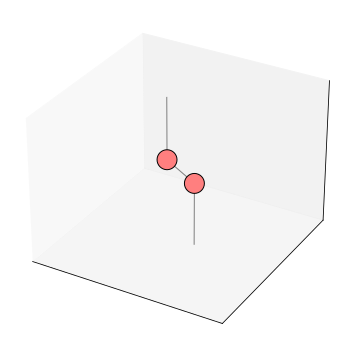

In [5]:
zx = g.to_zx_graph()
zx.draw()

In [6]:
cs = find_correlation_surfaces(zx.g)

In [7]:
for el in cs:
    print(el)

CorrelationSurface(span=frozenset({ZXEdge(u=ZXNode(id=0, basis=Basis.X), v=ZXNode(id=1, basis=Basis.X)), ZXEdge(u=ZXNode(id=2, basis=Basis.X), v=ZXNode(id=3, basis=Basis.X)), ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=2, basis=Basis.X))}))
CorrelationSurface(span=frozenset({ZXEdge(u=ZXNode(id=0, basis=Basis.Z), v=ZXNode(id=1, basis=Basis.Z)), ZXEdge(u=ZXNode(id=2, basis=Basis.Z), v=ZXNode(id=3, basis=Basis.Z)), ZXEdge(u=ZXNode(id=1, basis=Basis.Z), v=ZXNode(id=2, basis=Basis.Z))}))


In [8]:
g = PrismGraph("CNOT")

prisms = [
    (Position3DHex(3,3,0), "PORT", "target-int"),
    (Position3DHex(3,3,1), "NN", ""),
    (Position3DHex(3,3,2), "NN", ""),
    (Position3DHex(3,3,3), "PORT", "target-out"),

    (Position3DHex(2,2,1), "XN", ""),
    (Position3DHex(2,2,2), "NZ", ""),

    (Position3DHex(1,3,0), "PORT", "control-in"),
    (Position3DHex(1,3,1), "NN", ""),
    (Position3DHex(1,3,2), "NN", ""),
    (Position3DHex(1,3,3), "PORT", "control-out"),

]

for pos, kind, label in prisms:
    g.add_prism(pos, kind, label)

In [9]:
#c temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[0][0], prisms[1][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[1][0], prisms[2][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[2][0], prisms[3][0], pipe_kind)

#t temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[6][0], prisms[7][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[7][0], prisms[8][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[8][0], prisms[9][0], pipe_kind)

#spatial pipes
pipe_kind = PrismPipeKind(hor = BasisPrism.X, ver = BasisPrism.Z)
g.add_pipe(prisms[1][0], prisms[4][0], pipe_kind)

pipe_kind = PrismPipeKind(hor = BasisPrism.Z, ver = BasisPrism.X)
g.add_pipe(prisms[8][0], prisms[5][0], pipe_kind)

#middle temp
pipe_kind = PrismPipeKind(hor = BasisPrism.N, ver = BasisPrism.N)
g.add_pipe(prisms[4][0], prisms[5][0], pipe_kind)

In [10]:
g.view_as_html()

(<Figure size 500x600 with 1 Axes>, <Axes3D: >)

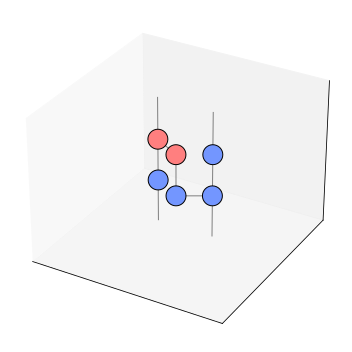

In [11]:
zx = g.to_zx_graph()
zx.draw()

In [12]:
cs = find_correlation_surfaces(zx.g)

In [13]:
for el in cs:
    print(el)

CorrelationSurface(span=frozenset({ZXEdge(u=ZXNode(id=7, basis=Basis.X), v=ZXNode(id=8, basis=Basis.X)), ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=4, basis=Basis.X)), ZXEdge(u=ZXNode(id=4, basis=Basis.X), v=ZXNode(id=5, basis=Basis.X)), ZXEdge(u=ZXNode(id=0, basis=Basis.X), v=ZXNode(id=1, basis=Basis.X)), ZXEdge(u=ZXNode(id=6, basis=Basis.X), v=ZXNode(id=7, basis=Basis.X)), ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=2, basis=Basis.X)), ZXEdge(u=ZXNode(id=2, basis=Basis.X), v=ZXNode(id=3, basis=Basis.X)), ZXEdge(u=ZXNode(id=5, basis=Basis.X), v=ZXNode(id=8, basis=Basis.X))}))
CorrelationSurface(span=frozenset({ZXEdge(u=ZXNode(id=8, basis=Basis.X), v=ZXNode(id=9, basis=Basis.X)), ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=4, basis=Basis.X)), ZXEdge(u=ZXNode(id=4, basis=Basis.X), v=ZXNode(id=5, basis=Basis.X)), ZXEdge(u=ZXNode(id=0, basis=Basis.X), v=ZXNode(id=1, basis=Basis.X)), ZXEdge(u=ZXNode(id=1, basis=Basis.X), v=ZXNode(id=2, basis=Basis.X)), ZXEdge(u=ZXNode(id

In [14]:
compile_correlation_surface_to_abstract_observable(g, cs[0])

TypeError: 'PositionedHexZX' object is not subscriptable

### template and plaquette examples in tqec so far

In [15]:
from tqec.templates.display import display_template
from tqec.templates.qubit import QubitTemplate

template = QubitTemplate()
display_template(template, 2)

  1   5   6   5   6   2
  7   9  10   9  10  11
  8  10   9  10   9  12
  7   9  10   9  10  11
  8  10   9  10   9  12
  3  13  14  13  14   4


In [16]:
k = 2
removed_plaquettes = {1, 2, 3, 4, 5, 8, 12, 14}
display_template(
    template, k, [i if i not in removed_plaquettes else 0 for i in range(1, 15)]
)

  .   .   6   .   6   .
  7   9  10   9  10  11
  .  10   9  10   9   .
  7   9  10   9  10  11
  .  10   9  10   9   .
  .  13   .  13   .   .


In [ ]:
"""
Surface code plaquette visualization — simple working examples.

Two approaches shown:

  Approach A: direct — template + plaquettes → SVG in ~10 lines.
              Most relevant for your color code work.

  Approach B: via LayerTree — compile a BlockGraph all the way to layers,
              then call layers_to_svg(). More powerful but more setup.

Run with:
    python surface_code_viz_simple.py

Outputs:
    direct_k1.svg, direct_k2.svg  — from Approach A
    layer_k2_<n>.svg              — one SVG per time layer from Approach B
"""

from pathlib import Path

# ===========================================================================
# APPROACH A — direct (10 lines, no compilation pipeline needed)
# ===========================================================================
#
# The two objects you always need as a matched pair:
#   template   → .instantiate_list(k) gives the 2D index grid
#   plaquettes → .collection maps each index to a Plaquette with a drawer
#
# plaquette_grid_svg_viewer(grid, drawers, top_left_used_qubit)
#   - grid: list[list[int]] from template.instantiate_list(k)
#   - drawers: FrozenDefaultDict[int, SVGPlaquetteDrawer] from plaquettes
#   - top_left_used_qubit: GridQubit — origin offset, GridQubit(0,0) is fine
#   - DO NOT pass width/height — the default (width=n_cols, height=n_rows)
#     makes each plaquette exactly 1 SVG unit wide so they touch edge-to-edge.
#     Passing width=n_cols*60 makes cells 60 units apart but drawings 1 unit
#     wide — that was the spacing bug in the previous version.

from tqec.circuit.qubit import GridQubit
from tqec.compile.specs.library.generators.fixed_bulk import FixedBulkConventionGenerator
from tqec.plaquette.compilation.base import IdentityPlaquetteCompiler
from tqec.plaquette.rpng.translators.default import DefaultRPNGTranslator
from tqec.visualisation.computation.plaquette.grid import plaquette_grid_svg_viewer

gen = FixedBulkConventionGenerator(DefaultRPNGTranslator(), IdentityPlaquetteCompiler)

template  = gen.get_memory_qubit_raw_template()   # QubitTemplate
plaquettes = gen.get_memory_qubit_plaquettes()     # Plaquettes (matched to template)

# Build one drawer per plaquette index from the debug information attached
# to each Plaquette.  For RPNG-based plaquettes this gives RPNGPlaquetteDrawer.
drawers = plaquettes.collection.map_values(
    lambda plaq: plaq.debug_information.get_svg_drawer()
)

for k in [1, 2]:
    grid = template.instantiate_list(k)            # list[list[int]], shape (2k+2)×(2k+2)
    svg  = plaquette_grid_svg_viewer(
        grid,
        drawers,
        top_left_used_qubit=GridQubit(0, 0),
        # No width/height → defaults to (n_cols × n_rows), plaquettes touch.
    )
    path = Path(f"direct_k{k}.svg")
    path.write_text(svg.as_str())
    print(f"[A] Written {path}  (grid {len(grid)}×{len(grid[0])}, d={2*k+1})")


# ===========================================================================
# APPROACH B — via LayerTree  (uses the full compilation pipeline)
# ===========================================================================
#
# This goes all the way from a BlockGraph through compile_block_graph() to
# a LayerTree, then calls layers_to_svg(k).  The result is one SVG per time
# layer (init layer, repeated memory layer, measurement layer).
#
# Use this when you want the annotated visualization that shows observable
# positions, error locations, etc.  For just "show me the stabilizers" you
# don't need it — Approach A is enough.

from tqec.computation.block_graph import BlockGraph
from tqec.compile.compile import compile_block_graph
from tqec.utils.position import Position3D

# Build a minimal single-qubit block graph (one cube, no pipes)
bg = BlockGraph("single_qubit")
bg.add_cube(Position3D(0, 0, 0), "zxz")   # a single ZXZ cube

# Fill ports is not needed here — no ports in a single cube.
# compile_block_graph returns a TopologicalComputationGraph.
compiled = compile_block_graph(bg)

# to_layer_tree() merges all spatial blocks into a unified LayerTree.
layer_tree = compiled.to_layer_tree()

# layers_to_svg(k) returns one SVG string per atomic time layer.
k = 2
svgs = layer_tree.layers_to_svg(k)
print(f"\n[B] {len(svgs)} layers at k={k}:")
for i, svg_text in enumerate(svgs):
    path = Path(f"layer_k{k}_{i}.svg")
    path.write_text(svg_text)
    print(f"    Written {path}  ({len(svg_text)} chars)")


[A] Written direct_k1.svg  (grid 4×4, d=3)
[A] Written direct_k2.svg  (grid 6×6, d=5)


'\n# ===========================================================================\n# APPROACH B — via LayerTree  (uses the full compilation pipeline)\n# ===========================================================================\n#\n# This goes all the way from a BlockGraph through compile_block_graph() to\n# a LayerTree, then calls layers_to_svg(k).  The result is one SVG per time\n# layer (init layer, repeated memory layer, measurement layer).\n#\n# Use this when you want the annotated visualization that shows observable\n# positions, error locations, etc.  For just "show me the stabilizers" you\n# don\'t need it — Approach A is enough.\n\nfrom tqec.computation.block_graph import BlockGraph\nfrom tqec.compile.compile import compile_block_graph\nfrom tqec.utils.position import Position3D\n\n# Build a minimal single-qubit block graph (one cube, no pipes)\nbg = BlockGraph("single_qubit")\nbg.add_cube(Position3D(0, 0, 0), "zxz")   # a single ZXZ cube\n\n# Fill ports is not needed here — n